# 02 — Sentiment scoring with FinBERT

Headlines are scored with [ProsusAI/finbert](https://huggingface.co/ProsusAI/finbert),
a BERT model fine-tuned on financial text. A finance-tuned model matters because
financial language inverts everyday polarity: "bull", "short covering",
"beat expectations", "cuts guidance" all confuse generic sentiment tools.

Each headline gets class probabilities (positive / negative / neutral) and one
signed score `sent_score = p_positive − p_negative` ∈ [−1, 1]. Scoring is
deterministic and cached to `data/processed/headline_sentiment.csv`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

from src.data import load_headlines
from src.sentiment import score_headlines

headlines = load_headlines()
scored = score_headlines(headlines)   # uses the cache if present
scored[["p_positive", "p_negative", "p_neutral", "sent_score"]].describe().round(3)

,p_positive,p_negative,p_neutral,sent_score
count,18153.000,18153.000,18153.000,18153.000
mean,0.202,0.267,0.531,-0.065
std,0.279,0.343,0.371,0.504
min,0.006,0.006,0.008,-0.968
25%,0.030,0.027,0.098,-0.322
50%,0.062,0.064,0.673,0.003
75%,0.219,0.456,0.898,0.133
max,0.958,0.977,0.956,0.938


## What the scores look like

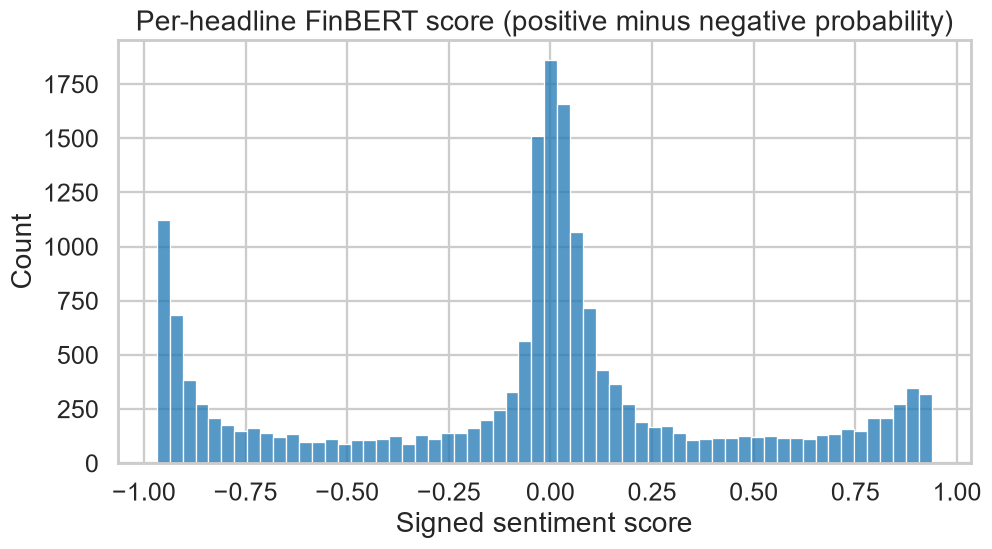

In [2]:
from src.plots import sentiment_distribution
sentiment_distribution(scored)
from IPython.display import Image
Image("../reports/figures/03_sentiment_distribution.png")

Most headlines are neutral (finance news is mostly descriptive), with clear
positive and negative tails — the expected shape for FinBERT on headlines.

In [3]:
print("Most negative headlines:")
for _, r in scored.nsmallest(5, "sent_score").iterrows():
    print(f"  {r.date.date()}  [{r.sent_score:+.2f}]  {r.headline[:95]}")
print()
print("Most positive headlines:")
for _, r in scored.nlargest(5, "sent_score").iterrows():
    print(f"  {r.date.date()}  [{r.sent_score:+.2f}]  {r.headline[:95]}")

Most negative headlines:
  2022-04-14  [-0.97]  S&P 500 Net Profit Margin is Expected to Decline for Third Straight Quarter
  2023-01-18  [-0.97]  S&P 500 Now Projected to Report Year-Over-Year Earnings Declines in Q1 2023 and Q2 2023
  2020-10-12  [-0.97]  Q3 Earnings: Analysts Expect Second-Largest Earnings Decline Since 2009
  2022-06-10  [-0.97]  These 19 large-cap stocks have now dropped at least 60% from their 52-week highs
  2023-07-17  [-0.97]  S&P 500 Will Likely Report a Decline in Earnings for 3rd Consecutive Quarter in Q2 2023

Most positive headlines:
  2018-07-03  [+0.94]  In the last five years, BSE 500 has given 5% higher annual returns compared to S&P 500 | Mint
  2022-06-01  [+0.94]  SureFire Capital's Multi-Strategy Hedge Fund Achieves +22.1% in April 2022, Outperforming the S
  2023-04-17  [+0.94]  Security Benefit Enhances its Foundations Annuity With New Indices for Greater Diversification
  2020-12-17  [+0.94]  Telephone & Data Systems Stock To Surpass Its Pre-Co

## Sanity check: does sentiment track known crises?

If the scorer works, average sentiment should drop sharply in windows where we
*know* the news was bad: the 2008 financial crisis, the 2011 US downgrade,
the 2020 COVID crash, the 2022 bear market.

In [4]:
from src.features import aggregate_daily, build_model_frame
from src.analysis import crisis_sentiment, crisis_windows
from src.plots import sentiment_and_price, crisis_bars, news_volume
from IPython.display import Image

df = build_model_frame(scored)
crisis_tbl = crisis_sentiment(df)
crisis_tbl.round(3)

,period,n_days,mean_sent,vs_full_sample
0,full sample,3507,-0.059,0.000
1,2008 financial crisis,66,-0.337,-0.278
2,2011 US downgrade,63,-0.066,-0.007
3,2020 COVID crash,41,-0.201,-0.142
4,2022 bear market,209,-0.110,-0.051


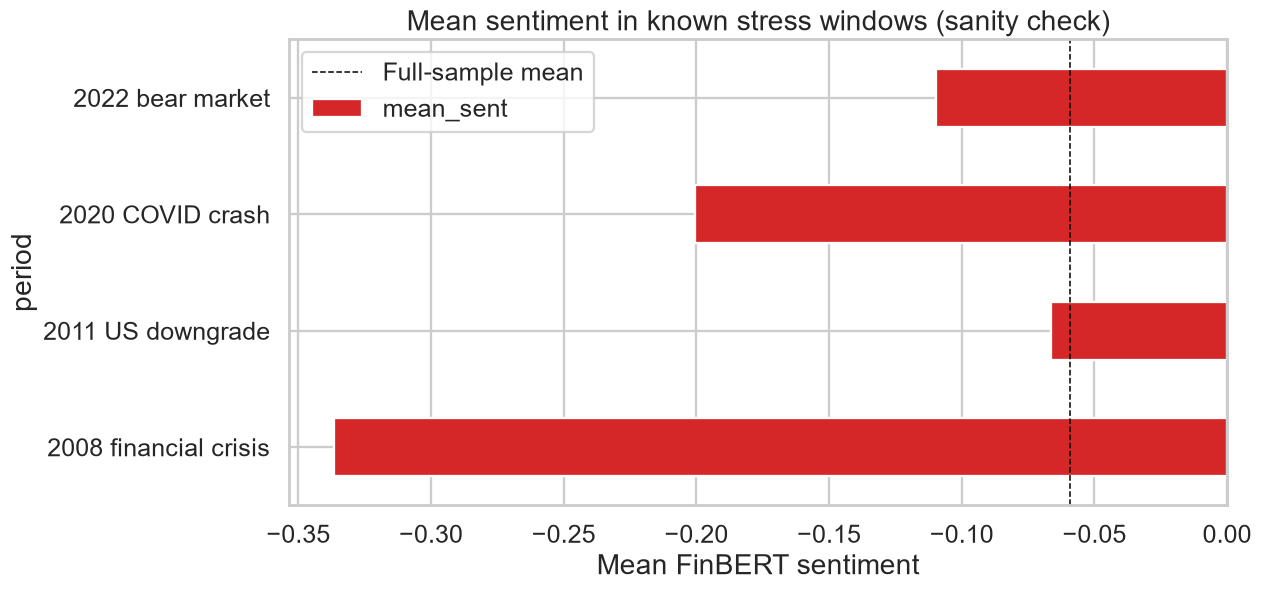

In [5]:
crisis_bars(crisis_tbl)
Image("../reports/figures/04_crisis_sanity_check.png")

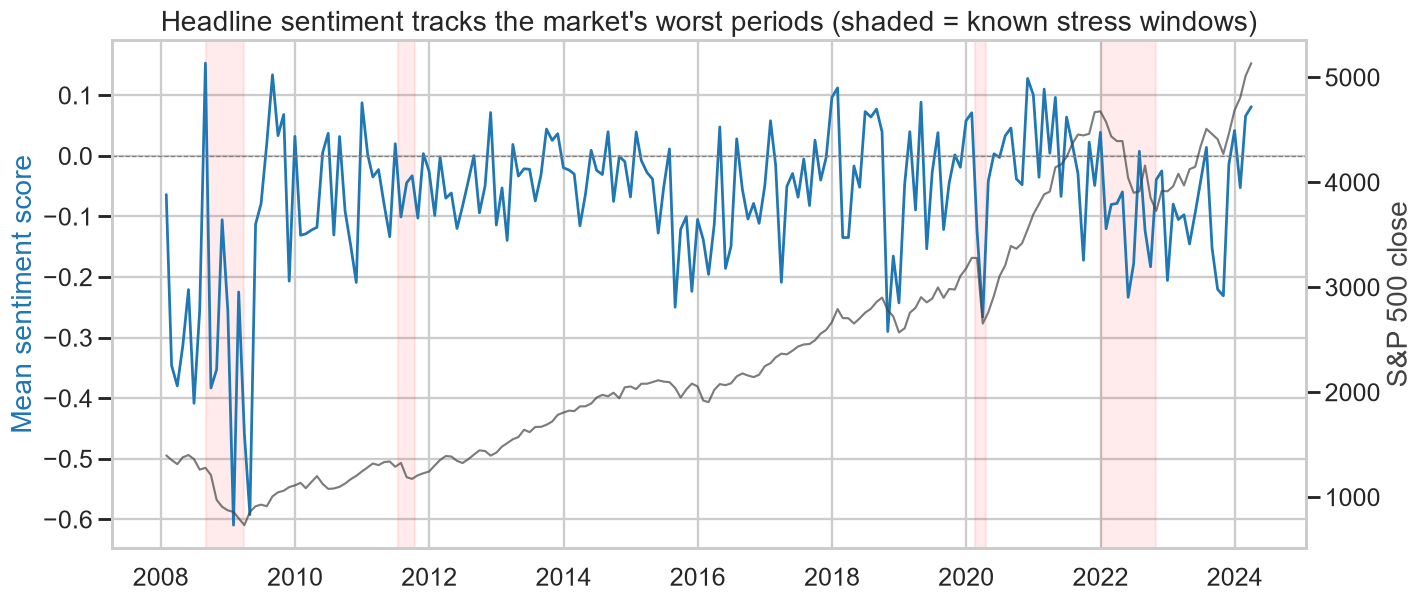

In [6]:
sentiment_and_price(df, crisis_windows())
Image("../reports/figures/01_sentiment_vs_price.png")

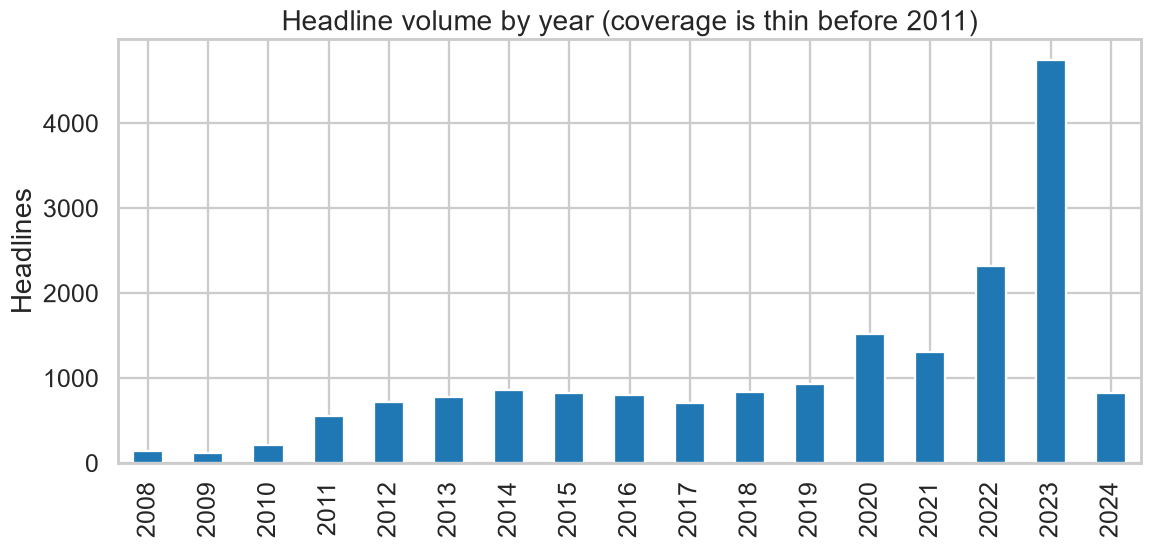

In [7]:
news_volume(df)
Image("../reports/figures/02_news_volume_by_year.png")

## Save the daily aggregate

Date-level aggregates (no headline text) are committed to the repo so the
correlation and modeling notebooks are reproducible without rerunning FinBERT.

In [8]:
daily_out = df[["date", "close", "ret", "next_ret", "gap_to_next", "next_day_ok",
                "sent_mean", "sent_median", "sent_std", "share_pos", "share_neg",
                "p_pos_mean", "p_neg_mean", "n_headlines"]]
daily_out.to_csv("../data/processed/daily_sentiment.csv", index=False)
print(f"saved {len(daily_out):,} rows -> data/processed/daily_sentiment.csv")

saved 3,507 rows -> data/processed/daily_sentiment.csv
